Using device: cpu
Vocab sizes: {'Usage': 19, 'VehType': 16, 'VehPower': 9}
Train / Val / Test: 49,974 / 10,709 / 10,709

Model created. Total parameters: 88,513

pos_weight for BCE loss: 6.89


C:\Users\miy\miniconda3\envs\diceml\lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch  1/10 | train_loss: 1.0169 | val_loss: 1.0090
Epoch  2/10 | train_loss: 1.0025 | val_loss: 1.0083
Epoch  3/10 | train_loss: 0.9996 | val_loss: 1.0049
Epoch  4/10 | train_loss: 0.9977 | val_loss: 1.0045
Epoch  5/10 | train_loss: 0.9955 | val_loss: 1.0047
Epoch  6/10 | train_loss: 0.9943 | val_loss: 1.0062
Epoch  7/10 | train_loss: 0.9942 | val_loss: 1.0092
Epoch  8/10 | train_loss: 0.9931 | val_loss: 1.0026
Epoch  9/10 | train_loss: 0.9923 | val_loss: 1.0049
Epoch 10/10 | train_loss: 0.9911 | val_loss: 1.0028


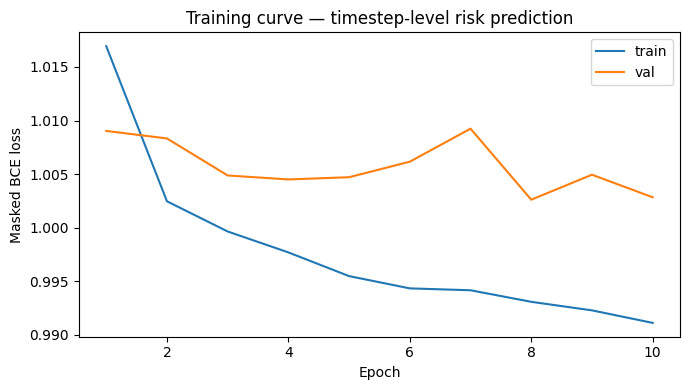


===== Test set evaluation (timestep-level) =====
Total timestep predictions: 54,755
AUC-ROC : 0.7682
F1-score: 0.3592
Positive rate in test: 12.79%

Saved: data/sequences/transformer_model.pt
Saved: data/sequences/test_predictions.npz

===== Transformer Model Summary =====
Architecture        : 2-layer Transformer Encoder, emb_dim=64, n_heads=4
Total parameters    : 88,513
Output granularity  : per-timestep risk logit (timestep-level prediction)
Loss                : masked BCE with pos_weight=6.89
Test AUC-ROC        : 0.7682
Test F1-score       : 0.3592


In [4]:
# ============================================================
# Notebook    : 03_transformer_model.ipynb
# Description : Define and train Transformer encoder for
#               timestep-level longitudinal risk prediction
#               - Each year in the sequence gets its own risk score
#               - Enables time-resolved SHAP analysis (Section 3-3)
#               - CPU-optimized: 2 layers, 64-dim embeddings
# ============================================================


# ============================================================
# 0. Install dependencies (run once)
# ============================================================
# pip install torch scikit-learn matplotlib


# ============================================================
# 1. Common imports
# ============================================================
import pickle
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cpu")
print("Using device:", DEVICE)


# ============================================================
# 2. Load sequences and vocabularies built in notebook 02
# ============================================================
with open("data/sequences/train_sequences.pkl", "rb") as f:
    train_seqs = pickle.load(f)
with open("data/sequences/val_sequences.pkl", "rb") as f:
    val_seqs = pickle.load(f)
with open("data/sequences/test_sequences.pkl", "rb") as f:
    test_seqs = pickle.load(f)

with open("data/sequences/vocabs.json", "r", encoding="utf-8") as f:
    vocabs = json.load(f)

vocab_sizes = {k: len(v) for k, v in vocabs.items()}
print("Vocab sizes:", vocab_sizes)
print(f"Train / Val / Test: {len(train_seqs):,} / {len(val_seqs):,} / {len(test_seqs):,}")


# ============================================================
# 3. Dataset and collate function
#    - Identical padding/mask logic as notebook 02
#    - label is now used per-timestep (not aggregated)
# ============================================================
class SequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx]

def collate_fn(batch):
    max_len = max(item["length"] for item in batch)
    batch_size = len(batch)
    n_numeric = batch[0]["numeric"].shape[1]
    n_cat     = batch[0]["cat_idx"].shape[1]

    numeric_padded = torch.zeros(batch_size, max_len, n_numeric, dtype=torch.float32)
    cat_idx_padded = torch.zeros(batch_size, max_len, n_cat, dtype=torch.long)
    label_padded   = torch.zeros(batch_size, max_len, dtype=torch.float32)
    attention_mask = torch.zeros(batch_size, max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]
        numeric_padded[i, :L] = torch.tensor(item["numeric"])
        cat_idx_padded[i, :L] = torch.tensor(item["cat_idx"])
        label_padded[i, :L]   = torch.tensor(item["label"], dtype=torch.float32)
        attention_mask[i, :L] = True

    return {
        "numeric": numeric_padded,
        "cat_idx": cat_idx_padded,
        "label":   label_padded,
        "mask":    attention_mask,
    }

BATCH_SIZE = 32  # reduced for CPU training

train_loader = DataLoader(SequenceDataset(train_seqs), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(SequenceDataset(val_seqs),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(SequenceDataset(test_seqs),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


# ============================================================
# 4. Model definition — Transformer Encoder + per-timestep head
#    - Each categorical feature (Usage, VehType, VehPower) gets
#      its own embedding, concatenated with numeric features
#    - Positional encoding uses YearGap directly (already a
#      numeric feature), so no separate sinusoidal PE needed —
#      the model learns position from YearGap itself
#    - Output: one risk logit PER TIMESTEP, not one per sequence
# ============================================================
class TimestepRiskTransformer(nn.Module):
    def __init__(self, vocab_sizes, n_numeric, emb_dim=64, n_heads=4,
                 n_layers=2, ff_dim=128, dropout=0.1):
        super().__init__()

        cat_cols = list(vocab_sizes.keys())
        self.cat_cols = cat_cols

        # one embedding table per categorical feature
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(vocab_sizes[col], emb_dim, padding_idx=0)
            for col in cat_cols
        })

        # project numeric features into the same embedding space
        self.numeric_proj = nn.Linear(n_numeric, emb_dim)

        # combine categorical embeddings + numeric projection
        combined_dim = emb_dim * (len(cat_cols) + 1)
        self.input_proj = nn.Linear(combined_dim, emb_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # per-timestep classification head -> one logit per year
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, 1),
        )

    def forward(self, numeric, cat_idx, attention_mask):
        # numeric: [B, T, n_numeric]
        # cat_idx: [B, T, n_cat]
        # attention_mask: [B, T] (True = real token)

        cat_embeds = []
        for i, col in enumerate(self.cat_cols):
            cat_embeds.append(self.embeddings[col](cat_idx[:, :, i]))  # [B, T, emb_dim]
        cat_embeds = torch.cat(cat_embeds, dim=-1)  # [B, T, emb_dim * n_cat]

        num_embed = self.numeric_proj(numeric)  # [B, T, emb_dim]

        combined = torch.cat([cat_embeds, num_embed], dim=-1)  # [B, T, combined_dim]
        x = self.input_proj(combined)  # [B, T, emb_dim]

        # Transformer expects True = position to IGNORE (padding),
        # but our attention_mask has True = real token, so invert it
        src_key_padding_mask = ~attention_mask  # [B, T]

        encoded = self.encoder(x, src_key_padding_mask=src_key_padding_mask)  # [B, T, emb_dim]

        logits = self.classifier(encoded).squeeze(-1)  # [B, T] -> one logit per timestep
        return logits


N_NUMERIC = 2  # Expo, YearGap
model = TimestepRiskTransformer(vocab_sizes=vocab_sizes, n_numeric=N_NUMERIC).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel created. Total parameters: {n_params:,}")


# ============================================================
# 5. Loss function — masked BCE per timestep
#    - Padding positions must NOT contribute to the loss
#    - pos_weight compensates for the 12.67% positive rate
#      found in notebook 01 (no synthetic oversampling used,
#      per user's decision to keep data untouched)
# ============================================================
POS_WEIGHT = torch.tensor((1 - 0.1267) / 0.1267)  # ~6.89
print(f"\npos_weight for BCE loss: {POS_WEIGHT.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT, reduction="none")

def masked_bce_loss(logits, labels, mask):
    loss = criterion(logits, labels)       # [B, T]
    loss = loss * mask.float()              # zero out padding positions
    return loss.sum() / mask.float().sum()  # average over real tokens only


# ============================================================
# 6. Training loop
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
N_EPOCHS = 10

train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_train_loss = 0.0
    n_batches = 0

    for batch in train_loader:
        numeric = batch["numeric"].to(DEVICE)
        cat_idx = batch["cat_idx"].to(DEVICE)
        label   = batch["label"].to(DEVICE)
        mask    = batch["mask"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(numeric, cat_idx, mask)
        loss = masked_bce_loss(logits, label, mask)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_train_loss / n_batches
    train_losses.append(avg_train_loss)

    # validation
    model.eval()
    epoch_val_loss = 0.0
    n_val_batches = 0
    with torch.no_grad():
        for batch in val_loader:
            numeric = batch["numeric"].to(DEVICE)
            cat_idx = batch["cat_idx"].to(DEVICE)
            label   = batch["label"].to(DEVICE)
            mask    = batch["mask"].to(DEVICE)

            logits = model(numeric, cat_idx, mask)
            loss = masked_bce_loss(logits, label, mask)
            epoch_val_loss += loss.item()
            n_val_batches += 1

    avg_val_loss = epoch_val_loss / n_val_batches
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch:2d}/{N_EPOCHS} | train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f}")


# ============================================================
# 7. Plot training curves
# ============================================================
plt.figure(figsize=(7, 4))
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train")
plt.plot(range(1, N_EPOCHS + 1), val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Masked BCE loss")
plt.title("Training curve — timestep-level risk prediction")
plt.legend()
plt.tight_layout()
plt.savefig("data/sequences/training_curve.png")
plt.show()


# ============================================================
# 8. Evaluation on test set — timestep-level metrics
#    - All padding positions excluded via mask before scoring
#    - AUC-ROC and F1 computed on flattened real-token predictions
# ============================================================
model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        numeric = batch["numeric"].to(DEVICE)
        cat_idx = batch["cat_idx"].to(DEVICE)
        label   = batch["label"].to(DEVICE)
        mask    = batch["mask"].to(DEVICE)

        logits = model(numeric, cat_idx, mask)

        # flatten and keep only real (non-padded) positions
        flat_logits = logits[mask]
        flat_labels = label[mask]

        all_logits.append(flat_logits.numpy())
        all_labels.append(flat_labels.numpy())

all_logits = np.concatenate(all_logits)
all_labels = np.concatenate(all_labels)
all_probs  = 1 / (1 + np.exp(-all_logits))  # sigmoid

auc = roc_auc_score(all_labels, all_probs)
f1  = f1_score(all_labels, (all_probs >= 0.5).astype(int))

print("\n===== Test set evaluation (timestep-level) =====")
print(f"Total timestep predictions: {len(all_labels):,}")
print(f"AUC-ROC : {auc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Positive rate in test: {all_labels.mean()*100:.2f}%")


# ============================================================
# 9. Save model and predictions
# ============================================================
torch.save(model.state_dict(), "data/sequences/transformer_model.pt")
print("\nSaved: data/sequences/transformer_model.pt")

np.savez(
    "data/sequences/test_predictions.npz",
    logits=all_logits,
    labels=all_labels,
    probs=all_probs,
)
print("Saved: data/sequences/test_predictions.npz")


# ============================================================
# 10. Summary check
# ============================================================
print("\n===== Transformer Model Summary =====")
print(f"Architecture        : 2-layer Transformer Encoder, emb_dim=64, n_heads=4")
print(f"Total parameters    : {n_params:,}")
print(f"Output granularity  : per-timestep risk logit (timestep-level prediction)")
print(f"Loss                : masked BCE with pos_weight={POS_WEIGHT.item():.2f}")
print(f"Test AUC-ROC        : {auc:.4f}")
print(f"Test F1-score       : {f1:.4f}")
print("======================================")

In [6]:
# ============================================================
# 11. (Optional) Find optimal threshold for F1 via PR curve
# ============================================================
precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold

print(f"Best threshold : {thresholds[best_idx]:.3f}")
print(f"Best F1-score  : {f1_scores[best_idx]:.4f}")
print(f"  Precision    : {precisions[best_idx]:.4f}")
print(f"  Recall       : {recalls[best_idx]:.4f}")

Best threshold : 0.670
Best F1-score  : 0.3790
  Precision    : 0.2749
  Recall       : 0.6097
